# BÀI TẬP TỰ LUẬN MACHINE LEARNING

---

## Bài 3.21: Ý TƯỞNG CƠ BẢN CỦA THUẬT TOÁN GRADIENT DESCENT

### 1. Ý tưởng cốt lõi
Gradient Descent (GD) là thuật toán tối ưu hóa lặp được sử dụng để tìm cực tiểu của hàm mất mát (loss function) $J(\theta)$. Thuật toán bắt đầu từ một điểm khởi tạo ngẫu nhiên, sau đó lặp lại việc bước từng bước ngược hướng với gradient của hàm mục tiêu tại điểm hiện tại để dần tiến về điểm tối ưu:
$$\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t)$$

### 2. Tại sao di chuyển ngược hướng với gradient?
* **Định nghĩa toán học của Gradient:** Gradient $\nabla J(\theta)$ là một vector chỉ theo **hướng tăng nhanh nhất** của hàm số tại điểm khảo sát.
* **Mục tiêu tối ưu:** Chúng ta muốn cực tiểu hóa (minimize) hàm chi phí. Do đó, hướng làm hàm số **giảm nhanh nhất** chính là hướng ngược lại với gradient ($-\nabla J(\theta)$).

### 3. Vai trò của tham số Learning Rate ($\eta$)
* Quyết định **kích thước bước nhảy** (step size) trong mỗi vòng lặp cập nhật trọng số.
* Là siêu tham số (hyperparameter) quan trọng nhất quyết định việc thuật toán có hội tụ hay không và tốc độ hội tụ nhanh hay chậm.

### 4. Điều kiện dừng của thuật toán
Thuật toán dừng khi thỏa mãn một trong các điều kiện sau:
1. **Đạt số vòng lặp tối đa (Max Epochs):** Ngăn việc lặp vô hạn.
2. **Độ lớn của gradient nhỏ hơn ngưỡng dung sai:** $\Vert{}\nabla J(\theta)\Vert{} < \varepsilon$ (tại đây bề mặt hàm số đã gần như nằm ngang, đạt cực trị địa phương/toàn cục).
3. **Mức thay đổi hàm mất mát hoặc trọng số quá nhỏ:** $\vert{}J(\theta_{t+1}) - J(\theta_t)\vert{} < \varepsilon$ hoặc $\Vert{}\theta_{t+1} - \theta_t\Vert{} < \varepsilon$.


## Bài 3.22: SO SÁNH BGD, SGD VÀ MBGD

| Tiêu chí | Batch Gradient Descent (BGD) | Stochastic Gradient Descent (SGD) | Mini-batch Gradient Descent (MBGD) |
| :--- | :--- | :--- | :--- |
| **Dữ liệu dùng mỗi lần cập nhật** | Toàn bộ tập dữ liệu huấn luyện ($N$ mẫu). | Duy nhất **1** mẫu dữ liệu được chọn ngẫu nhiên. | Một tập con kích thước nhỏ (**batch size** từ 16, 32, 64,... đến 512). |
| **Chi phí tính toán / 1 lần cập nhật** | Rất cao, đòi hỏi nạp toàn bộ dữ liệu vào bộ nhớ. | Cực kỳ thấp và nhanh vì chỉ tính toán trên 1 mẫu. | Trung bình, tính toán tối ưu nhờ khả năng xử lý vector hóa (GPU/CPU). |
| **Đường đi & Tốc độ hội tụ** | Đường đi mịn, thẳng đều đến cực trị; nhưng mỗi epoch rất chậm trên dữ liệu lớn. | Dao động mạnh (noisy), biến thiên liên tục quanh điểm cực trị; hội tụ nhanh ở giai đoạn đầu. | Đường đi tương đối mịn, dao động vừa phải; tốc độ hội tụ tổng thể nhanh và ổn định nhất. |
| **Ưu điểm** | - Gradient chính xác.<br>- Hội tụ ổn định. | - Tránh tràn RAM.<br>- Dao động mạnh giúp dễ thoát khỏi cực tiểu địa phương cạn (local minima). | - Cân bằng hoàn hảo giữa BGD và SGD.<br>- Tận dụng tối đa sức mạnh tính toán song song phần cứng. |
| **Nhược điểm** | - Dễ tràn bộ nhớ khi dữ liệu lớn.<br>- Dễ kẹt ở điểm yên ngựa (saddle points) hoặc cực tiểu địa phương. | - Mất tính ổn định khi gần điểm hội tụ.<br>- Không tận dụng được tính toán song song vector. | - Phải tinh chỉnh thêm siêu tham số `batch_size`. |
| **Trường hợp áp dụng** | Dữ liệu quy mô nhỏ, hàm lỗi khả vi trơn tru. | Dữ liệu luồng trực tuyến (online learning) hoặc tập dữ liệu cực lớn. | **Tiêu chuẩn mặc định** cho hầu hết các bài toán Deep Learning và Machine Learning hiện nay. |



## Bài 3.23: ẢNH HƯỞNG CỦA LEARNING RATE ĐẾN QUÁ TRÌNH TỐI ƯU CỦA GRADIENT DESCENT

### 1. Phân tích các trường hợp:
* **Learning rate quá nhỏ ($\eta \to 0$):**
  * Kích thước bước nhảy quá bé.
  * Thuật toán mất rất nhiều thời gian/vòng lặp để hội tụ, dễ cạn kiệt tài nguyên tính toán hoặc dừng sớm trước khi tới điểm cực trị.
* **Learning rate quá lớn ($\eta \gg 0$):**
  * Bước nhảy vượt qua điểm cực tiểu (overshooting).
  * Hàm mất mát dao động dữ dội và có thể bị **phân kỳ** (diverge), làm giá trị hàm mất mát tiến tới vô cùng (`NaN` / `inf`).
* **Learning rate hợp lý:**
  * Thuật toán tiến đều đặn về điểm cực tiểu sau một số lượng vòng lặp vừa phải.
  * Đạt trạng thái ổn định khi bước nhảy tự động thu nhỏ lại do $\nabla J(\theta) \to 0$.

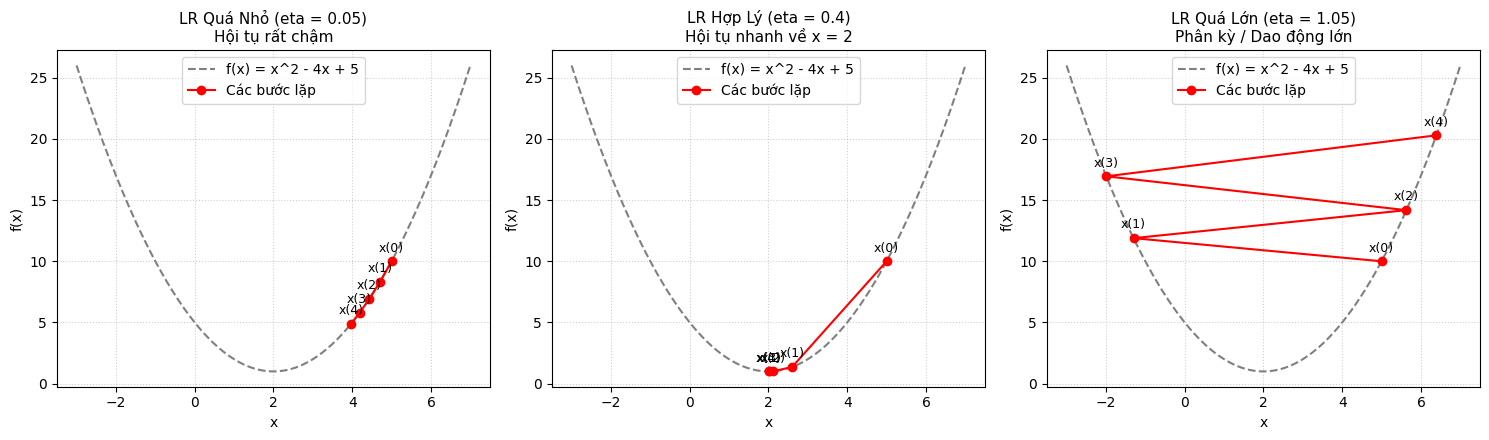

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x**2 - 4*x + 5

def df(x):
    return 2*x - 4

def gradient_descent(lr, x_init=5.0, steps=4):
    x_hist = [x_init]
    curr_x = x_init
    for _ in range(steps):
        curr_x = curr_x - lr * df(curr_x)
        x_hist.append(curr_x)
    return np.array(x_hist)

# 3 kịch bản Learning Rate
lrs = [0.05, 0.4, 1.05]
titles = [
    'LR Quá Nhỏ (eta = 0.05)\nHội tụ rất chậm',
    'LR Hợp Lý (eta = 0.4)\nHội tụ nhanh về x = 2',
    'LR Quá Lớn (eta = 1.05)\nPhân kỳ / Dao động lớn'
]

x_plot = np.linspace(-3, 7, 300)
plt.figure(figsize=(15, 4.5))

for i, lr in enumerate(lrs):
    path = gradient_descent(lr=lr, x_init=5.0, steps=4)
    plt.subplot(1, 3, i + 1)
    plt.plot(x_plot, f(x_plot), 'gray', linestyle='--', label='f(x) = x^2 - 4x + 5')
    plt.plot(path, f(path), 'ro-', markersize=6, label='Các bước lặp')
    
    # Đánh số thứ tự các bước trên đồ thị
    for step_idx, (px, py) in enumerate(zip(path, f(path))):
        plt.annotate(f'x({step_idx})', (px, py), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9)
        
    plt.title(titles[i], fontsize=11)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

---

## Bài 3.24: NGUYÊN LÝ HOẠT ĐỘNG CỦA THUẬT TOÁN PERCEPTRON

### 1. Bài toán giải quyết
* Perceptron (PLA - Perceptron Learning Algorithm) giải quyết bài toán **phân lớp nhị phân** (binary classification) với nhãn $y \in \{-1, +1\}$ (hoặc $\{0, 1\}$).
* Điều kiện áp dụng hoàn hảo: Dữ liệu phải có tính chất **phân tách tuyến tính** (linearly separable).

### 2. Khái niệm siêu phẳng phân tách (Separating Hyperplane)
* Trong không gian $d$ chiều, siêu phẳng phân tách là mặt phẳng có số chiều $d-1$, được xác định bởi phương trình:
$$w^T x + b = 0 \quad \text{hoặc} \quad w_0 + w_1 x_1 + \dots + w_d x_d = 0$$
* Siêu phẳng chia toàn bộ không gian làm 2 nửa: một nửa không gian mang dấu dương ($> 0$), nửa còn lại mang dấu âm ($< 0$).

### 3. Cách dự đoán nhãn của một mẫu mới
* Tính tổng có trọng số: $z = w^T x + b$
* Đưa qua hàm kích hoạt Signum (hàm dấu):
$$\hat{y} = \text{sign}(w^T x + b) = \begin{cases} +1 & \text{khi } w^T x + b \ge 0 \\ -1 & \text{khi } w^T x + b < 0 \end{cases}$$

### 4. Quy tắc cập nhật trọng số
Perceptron chỉ cập nhật trọng số khi có điểm bị **phân loại sai** (misclassified point), tức là:
$$y_i (w^T x_i + b) \le 0$$

Quy tắc cập nhật:
$$\begin{aligned}
w &\leftarrow w + \eta \cdot y_i \cdot x_i \\
b &\leftarrow b + \eta \cdot y_i
\end{aligned}$$
*(Trong đó $\eta \in (0, 1]$ là learning rate. Nếu điểm phân loại đúng thì giữ nguyên trọng số).*

---

## Bài 3.25: CÁC ĐỘ ĐO ĐÁNH GIÁ MÔ HÌNH PHÂN LỚP

### 1. Giải thích các độ đo (Dựa trên Confusion Matrix: TP, TN, FP, FN)
* **Accuracy (Độ chính xác tổng thể):**
  $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
  * Ý nghĩa: Tỷ lệ số mẫu dự đoán đúng trên tổng toàn bộ số lượng mẫu khảo sát.
* **Precision (Độ chuẩn xác):**
  $$\text{Precision} = \frac{TP}{TP + FP}$$
  * Ý nghĩa: Trong tất cả các mẫu mô hình **dự đoán là Positive**, có bao nhiêu phần trăm là **thực sự Positive**.
* **Recall (Độ nhạy / Độ bao phủ):**
  $$\text{Recall} = \frac{TP}{TP + FN}$$
  * Ý nghĩa: Trong tất cả các mẫu **thực tế là Positive**, mô hình đã **tìm ra và bắt trúng** được bao nhiêu phần trăm.
* **F1-score:**
  $$\text{F1-score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
  * Ý nghĩa: Trung bình điều hòa (harmonic mean) giữa Precision và Recall; cân bằng khi dữ liệu mất cân bằng.

---

### 2. Đánh giá trong bài toán phát hiện bệnh và gian lận giao dịch

#### Trong hai bài toán này, độ đo nào quan trọng hơn Accuracy?
* **Độ đo quan trọng nhất là Recall**, kết hợp đánh giá bổ trợ bằng **F1-score** hoặc **Precision**.

#### Giải thích lý do:
1. **Hiện tượng mất cân bằng lớp (Imbalanced Data):**
   * Số lượng người khỏe mạnh hoặc giao dịch hợp lệ chiếm đa số tuyệt đối (ví dụ 99.9%), trong khi ca bệnh hoặc gian lận chỉ chiếm tỷ lệ rất nhỏ (0.1%).
   * Một mô hình ngây thơ (naive model) luôn đoán "Tất cả đều Bình thường" sẽ dễ dàng đạt **Accuracy = 99.9%**, nhưng thực chất mô hình hoàn toàn **vô dụng** vì không phát hiện được bất kỳ ca bệnh/gian lận nào.
2. **Cái giá phải trả của việc bỏ sót (FN - False Negative) là quá đắt:**
   * **Phát hiện bệnh:** Một ca bệnh hiểm nghèo bị bỏ sót (FN) có thể dẫn đến nguy hiểm tính mạng vì không được can thiệp y tế kịp thời. Đoán nhầm người khỏe thành nghi nhiễm (FP) chỉ tốn thêm chi phí làm xét nghiệm lại.
   * **Gian lận tài chính:** Bỏ lọt một giao dịch lừa đảo giá trị lớn (FN) gây thất thoát tài sản trực tiếp và rủi ro pháp lý; trong khi cảnh báo nhầm (FP) chỉ cần xác thực lại qua mã OTP hoặc liên hệ khách hàng.

# CHƯƠNG 2: CÁC PHƯƠNG PHÁP ĐÁNH GIÁ VÀ TỐI ƯU MÔ HÌNH HỌC MÁY

---

## 2.21. Khái niệm Overfitting và Underfitting

### 1. Khái niệm
* **Overfitting (Quá khớp):**
  * Là hiện tượng mô hình học quá mức cần thiết trên tập dữ liệu huấn luyện (học cả nhiễu và các chi tiết ngẫu nhiên không mang tính tổng quát).
  * Mô hình hoạt động rất tốt trên tập huấn luyện nhưng dự đoán kém trên dữ liệu mới (khả năng tổng quát hóa thấp). Mô hình có độ phức tạp cao, đặc trưng bởi **High Variance (Phương sai cao)**.
* **Underfitting (Chưa khớp):**
  * Là hiện tượng mô hình quá đơn giản, không đủ năng lực biểu diễn để nắm bắt được cấu trúc quy luật tiềm ẩn trong dữ liệu.
  * Mô hình thể hiện kết quả kém trên cả tập huấn luyện lẫn dữ liệu mới. Đặc trưng bởi **High Bias (Độ chệch cao)**.

---

### 2. Cách nhận biết thông qua Training Error và Test Error

| Hiện tượng | Training Error | Test / Validation Error | Đặc điểm nhận dạng |
| :--- | :---: | :---: | :--- |
| **Bình thường (Good Fit)** | Thấp | Thấp | Cả hai sai số đều nhỏ và chênh lệch giữa chúng không đáng kể. |
| **Underfitting (Chưa khớp)** | **Rất cao** | **Rất cao** | Cả hai sai số đều lớn xấp xỉ nhau (ngay cả trên dữ liệu đã học mô hình vẫn đoán sai nhiều). |
| **Overfitting (Quá khớp)** | **Rất thấp** ($\to 0$) | **Rất cao** | Khoảng cách chênh lệch giữa Test Error và Training Error là rất lớn ($\text{Test Error} \gg \text{Training Error}$). |

---

## 2.22. Nguyên lý hoạt động của K-Fold Cross Validation

### 1. Nguyên lý hoạt động
K-Fold Cross Validation (Kiểm định chéo K-lần) là kỹ thuật đánh giá hiệu năng tổng quát hóa của mô hình và phòng tránh rò rỉ dữ liệu / quá khớp.

Quy trình thực hiện gồm các bước:
1. **Phân chia dữ liệu:** Tập dữ liệu ban đầu gồm $N$ mẫu được xáo trộn ngẫu nhiên và chia đều thành $K$ phần con (folds) có kích thước bằng nhau: $F_1, F_2, \dots, F_K$ (thông thường chọn $K = 5$ hoặc $K = 10$).
2. **Quá trình lặp kiểm định ($K$ vòng lặp):**
   * Tại vòng lặp thứ $i$ ($i = 1, \dots, K$):
     * Fold thứ $i$ ($F_i$) được giữ lại làm **Validation Set** (tập kiểm định).
     * Toàn bộ $(K - 1)$ fold còn lại được gộp làm **Training Set** (tập huấn luyện).
     * Huấn luyện mô hình trên Training Set và tính toán độ đo sai số/hiệu năng $E_i$ trên Validation Set.
3. **Tổng hợp kết quả:**
   * Hiệu năng cuối cùng của mô hình là trung bình cộng sai số qua $K$ lần lặp:
     $$E_{\text{CV}} = \frac{1}{K} \sum_{i=1}^K E_i$$

### 2. Ý nghĩa
* Tận dụng tối đa tập dữ liệu: mỗi mẫu dữ liệu đều được tham gia kiểm định đúng 1 lần và tham gia huấn luyện $(K-1)$ lần.
* Đánh giá khách quan, giảm thiểu sự phụ thuộc vào cách phân chia tập dữ liệu ngẫu nhiên một lần (train/test split đơn thuần).

---

## 2.23. Kỹ thuật Early Stopping

### 1. Khái niệm Early Stopping
* Early Stopping (Dừng sớm) là kỹ thuật theo dõi hàm mất mát (loss) hoặc độ đo hiệu năng trên **tập kiểm định (validation set)** qua từng epoch huấn luyện lặp (ví dụ trong Gradient Descent hoặc Mạng nơ-ron).
* Thuật toán sẽ chủ động dừng việc cập nhật trọng số trước khi đạt số epoch tối đa nếu sai số trên validation set bắt đầu tăng liên tục qua một số chu kỳ nhất định (gọi là tham số `patience`), đồng thời lưu lại bộ trọng số cho kết quả validation tốt nhất.

### 2. Vì sao Early Stopping được xem là một phương pháp Regularization?
Regularization là tập hợp các kỹ thuật nhằm hạn chế tính phức tạp của mô hình để kiểm soát hiện tượng Overfitting:
1. **Hạn chế độ lớn của không gian trọng số:**
   * Ở các bước lặp đầu, các trọng số thường bắt đầu từ giá trị rất nhỏ quanh 0. Khi số vòng lặp càng nhiều, trọng số dần tăng độ lớn để khớp cả những điểm nhiễu.
   * Ngắt sớm quá trình huấn luyện giữ cho độ lớn của vector trọng số $\Vert{}w\Vert{}$ ở mức nhỏ, tương đương về mặt toán học với việc ràng buộc độ lớn trọng số của kỹ thuật $L_2$ Regularization (Ridge).
2. **Kiểm soát độ phức tạp hiệu dụng (Effective Capacity):**
   * Early Stopping giới hạn số bước tối ưu hóa, ngăn mô hình tự do uốn lượn để bám theo từng mẫu ngoại lai trong tập huấn luyện, từ đó giúp mặt quyết định trơn hơn và duy trì khả năng tổng quát hóa cao.

---

## 2.24. So sánh LASSO Regularization và RIDGE Regularization

| Tiêu chí | LASSO Regularization ($L_1$) | RIDGE Regularization ($L_2$) |
| :--- | :--- | :--- |
| **Công thức hàm mất mát** | $$J(w) = \text{MSE}(w) + \lambda \sum_{j=1}^d \|w_j\|$$ | $$J(w) = \text{MSE}(w) + \lambda \sum_{j=1}^d w_j^2$$ |
| **Cơ chế hoạt động** | Cộng thêm thành phần phạt là **chuẩn bậc một ($L_1$-norm)** của vector trọng số. Vùng ràng buộc có dạng hình thoi (góc nhọn tại các trục tọa độ), khiến nghiệm tối ưu dễ tiếp xúc tại các đỉnh trục. | Cộng thêm thành phần phạt là **chuẩn bậc hai ($L_2$-norm)** của vector trọng số. Vùng ràng buộc có dạng hình cầu trơn (hình tròn trong 2D), ép các trọng số đồng loạt co cụm về gần 0 nhưng không bằng 0. |
| **Khả năng lựa chọn đặc trưng (Feature Selection)** | **Có.** Có khả năng triệt tiêu hoàn toàn trọng số của các đặc trưng không quan trọng về đúng **bằng 0** ($w_j = 0$), tạo ra mô hình thưa (sparse model). | **Không.** Chỉ thu nhỏ độ lớn của trọng số tiệm cận 0 ($w_j \approx 0$), vẫn giữ lại tất cả các đặc trưng trong mô hình. |
| **Trường hợp sử dụng phù hợp** | - Dữ liệu có số chiều cao ($p \gg n$), nhiều đặc trưng thừa hoặc không có ý nghĩa.<br>- Cần giải thích mô hình đơn giản, rõ ràng. | - Dữ liệu xảy ra hiện tượng **đa cộng tuyến** (multicollinearity - các đặc trưng tương quan mạnh với nhau).<br>- Hầu hết các đặc trưng đều có đóng góp vào kết quả đầu ra. |

---

## 2.25. Xây dựng mô hình hồi quy (Bài toán dự báo giá nhà)

Chúng ta sử dụng tập dữ liệu kinh điển California Housing (dự báo giá nhà trung bình), áp dụng tiền xử lý chuẩn hóa, tìm kiếm siêu tham số cho các mô hình hồi quy (Linear Regression, Ridge, Lasso, Random Forest), và đánh giá theo 4 độ đo:
1. **$R^2$ (Hệ số xác định):**
   $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
2. **NSE (Nash-Sutcliffe Efficiency):** 
   Về mặt công thức toán học đối với bài toán hồi quy tĩnh, chỉ số NSE tương đương với $R^2$:
   $$\text{NSE} = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$
3. **MAE (Sai số tuyệt đối trung bình):**
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
4. **RMSE (Căn bậc hai sai số toàn phương trung bình):**
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Tải tập dữ liệu California Housing (Bài toán dự báo giá nhà)
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# 2. Phân chia Train/Test theo tỷ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Định nghĩa hàm tính toán các độ đo (R2, NSE, MAE, RMSE)
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    # NSE có công thức tương đồng với R2 trên tập kiểm định tĩnh
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, nse, mae, rmse

# 5. Huấn luyện và đánh giá nhiều mô hình
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    # Huấn luyện
    if "Random Forest" in name:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    
    # Tính các độ đo
    r2, nse, mae, rmse = compute_metrics(y_test, y_pred)
    results.append({
        "Model": name,
        "R2": round(r2, 4),
        "NSE": round(nse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4)
    })

# 6. Trình bày kết quả dạng bảng so sánh
df_results = pd.DataFrame(results)
print("BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY:")
display(df_results)

best_model = df_results.sort_values(by="RMSE").iloc[0]
print(f"\n=> Mô hình đạt kết quả tốt nhất: {best_model['Model']} với R2 = {best_model['R2']} và RMSE = {best_model['RMSE']}")

BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY:


,Model,R2,NSE,MAE,RMSE
0,Linear Regression,0.5758,0.5758,0.5332,0.7456
1,Ridge Regression,0.5758,0.5758,0.5332,0.7456
2,Lasso Regression,0.5816,0.5816,0.5353,0.7404
3,Random Forest Regressor,0.8006,0.8006,0.3329,0.5111



=> Mô hình đạt kết quả tốt nhất: Random Forest Regressor với R2 = 0.8006 và RMSE = 0.5111
